In [140]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
plt.rcParams.update({'font.size': 16, 'figure.figsize': (8, 8)})
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",   # closest math font to Times
})

## Problem 1: Earth-Sun Two-Body Problem

The restricted two-body problem of the Earth orbiting the Sun is considered. The Sun is assumed to be fixed at the origin and unaffected by Earth's gravity. Earth is initialized at a distance $r_0 = 1$ AU with the circular orbital velocity:
$$v_{circ} = \sqrt{\frac{GM_\odot}{r_0}}$$
Natural astronomical units are used where $G = 4\pi^2 \dfrac{\text{AU}^3}{\text{M}_\odot \, \text{yr}^2}$, distances are in AU, and time is in years. The equations of motion are integrated for at least 3 orbital periods using both the **Euler** and **Leapfrog** methods.

In [141]:
#  Constants (in astronomical units)
G  = 4 * np.pi**2          
M  = 1.0    #Mass of the sun               
GM = G * M                 

In [142]:
def acceleration(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    
    return ax, ay

In [143]:
# Euler Method

def euler_method(x0,y0,vx0,vy0,h,N):
    x = np.zeros(N+1)  
    y = np.zeros(N+1)
    vx = np.zeros(N+1)  
    vy = np.zeros(N+1)
    x[0] = x0
    y[0] = y0
    vx[0] = vx0
    vy[0] = vy0

    for i in range(N):

        ax , ay = acceleration(x[i],y[i])
        # Velocity update
        vx[i+1] = vx[i] + ax * h
        vy[i+1] = vy[i] + ay * h

        # Position update
        x[i+1] = x[i] + vx[i] * h
        y[i+1] = y[i] + vy[i] * h

    return x,y,vx,vy


In [144]:
def Leapfrog_method(x0,y0,vx0,vy0,h,N):
    x = np.zeros(N+1)  
    y = np.zeros(N+1)
    vx = np.zeros(N+1)  
    vy = np.zeros(N+1)
    x[0] = x0
    y[0] = y0
    vx[0] = vx0
    vy[0] = vy0

    for i in range(N):
        ax, ay = acceleration(x[i],y[i])
        vxhalf = vx[i] + 0.5 * ax * h
        vyhalf = vy[i] + 0.5 * ay * h

        x[i+1] = x[i] + vxhalf * h
        y[i+1] = y[i] + vyhalf * h

        ax, ay = acceleration(x[i+1],y[i+1])

        vx[i+1] = vxhalf + 0.5 * ax * h
        vy[i+1] = vyhalf + 0.5 * ay * h

    return x,y,vx,vy


In [145]:
#  Initial conditions – circular orbit at r0 = 1 AU
r0 = 1.0                            # initial distance [AU]
v_circ = np.sqrt(GM / r0)           # circular speed [AU/yr]  => 2*pi AU/yr

x0 = r0
y0 = 0
vx0 = 0
vy0 = v_circ

#  Simulation parameters

T = 3.0             # 3 orbital periods
dt= 1e-3            # time step [yr](This is the step size h)
N = int(T / dt)

x1,y1,vx1,vy1 = euler_method(x0,y0,vx0,vy0,dt, N)
x2,y2,vx2,vy2 = Leapfrog_method(x0,y0,vx0,vy0,dt, N)

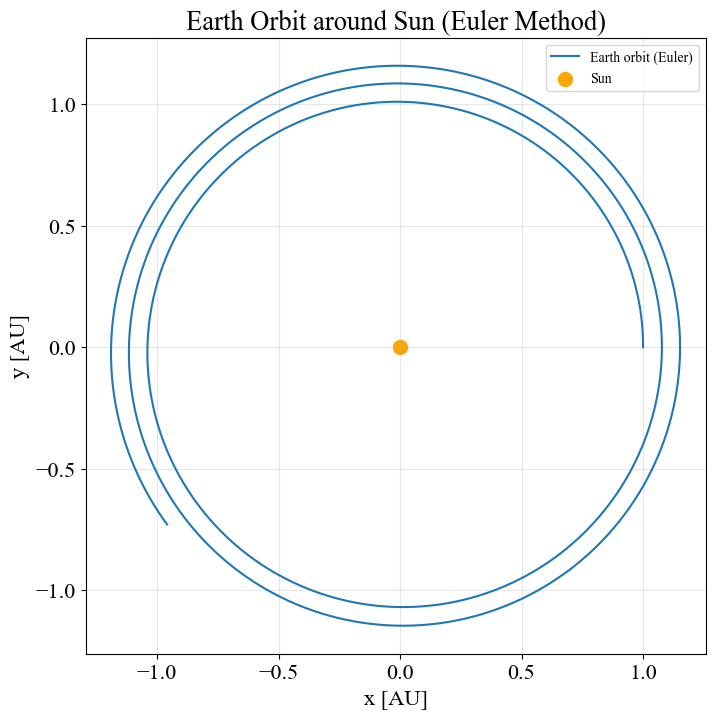

In [146]:
# Plotting the orbit for Euler method
plt.plot(x1, y1, label='Earth orbit (Euler)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Euler Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc='upper right',fontsize=10)
plt.savefig("1_Euler_orbit.png", dpi=150, bbox_inches='tight')
plt.show()

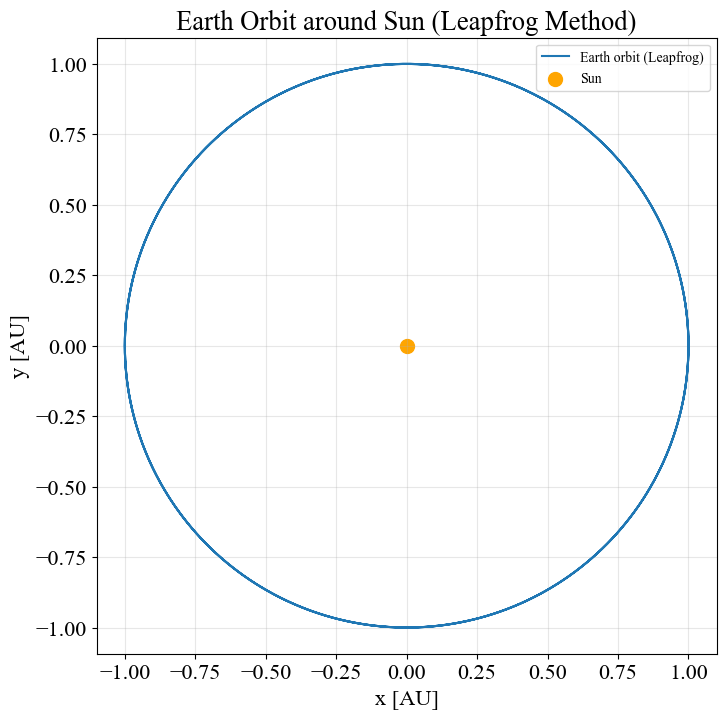

In [147]:
# Plotting the orbit for Leapfrog method
plt.plot(x2, y2, label='Earth orbit (Leapfrog)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Leapfrog Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc='upper right',fontsize=10)
plt.savefig("1_Leapfrog_orbit.png", dpi=150, bbox_inches='tight')
plt.show()

In [148]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Earth Orbiting the Sun (Euler Method)')

# Sun and Earth
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)
orbit_line, = ax.plot([], [], 'b-', lw=1)
earth_dot, = ax.plot([], [], 'bo', markersize=10, label='Earth', zorder=10)

ax.legend(loc='upper right', fontsize = 12)

def init():
    orbit_line.set_data([], [])
    earth_dot.set_data([], [])
    return orbit_line, earth_dot

# Slow down by using fewer points per frame
points_per_frame = 15  # smaller = slower orbit

def update(i):
    idx = i * points_per_frame
    if idx >= len(x1): idx = len(x1) - 1
    
    orbit_line.set_data(x1[:idx], y1[:idx])
    earth_dot.set_data([x1[idx]], [y1[idx]])
    return orbit_line, earth_dot

# Increase interval to 50ms for smoother slower motion
ani = FuncAnimation(fig, update, frames=len(x1)//points_per_frame, 
                    init_func=init, blit=False, interval=50, repeat=False)

ani.save('1_Euler_orbit.mp4', writer='ffmpeg', fps=30)
plt.close()
display(HTML(ani.to_html5_video()))

In [149]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Earth Orbiting the Sun: Euler vs Leapfrog')

# Sun
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)

# Orbit lines
orbit_line_euler, = ax.plot([], [], 'b-', lw=1)
orbit_line_leap, = ax.plot([], [], 'r-', lw=1)

# Moving dots
earth_dot_euler, = ax.plot([], [], 'bo', markersize=8, label='Earth (Euler)', zorder=10)
earth_dot_leap, = ax.plot([], [], 'ro', markersize=8, label='Earth (Leapfrog)', zorder=10)

ax.legend(loc='upper right',fontsize=12)

def init():
    orbit_line_euler.set_data([], [])
    orbit_line_leap.set_data([], [])
    earth_dot_euler.set_data([], [])
    earth_dot_leap.set_data([], [])
    return orbit_line_euler, orbit_line_leap, earth_dot_euler, earth_dot_leap

points_per_frame = 15  # slower animation

def update(i):
    idx = i * points_per_frame
    if idx >= len(x1): idx = len(x1) - 1  # handle last frame
    
    # Euler orbit
    orbit_line_euler.set_data(x1[:idx], y1[:idx])
    earth_dot_euler.set_data([x1[idx]], [y1[idx]])
    
    # Leapfrog orbit
    orbit_line_leap.set_data(x2[:idx], y2[:idx])
    earth_dot_leap.set_data([x2[idx]], [y2[idx]])
    
    return orbit_line_euler, orbit_line_leap, earth_dot_euler, earth_dot_leap

ani = FuncAnimation(fig, update, frames=len(x1)//points_per_frame, 
                    init_func=init, blit=False, interval=50, repeat=False)
ani.save('1_Leapfrog_orbit.mp4', writer='ffmpeg', fps=30)
plt.close()
display(HTML(ani.to_html5_video()))

### 1b: Speed vs Time
The orbital speed $v = \sqrt{v_x^2 + v_y^2}$ is computed at each timestep and plotted as a function of time for both the Euler and Leapfrog methods over 3 orbital periods.

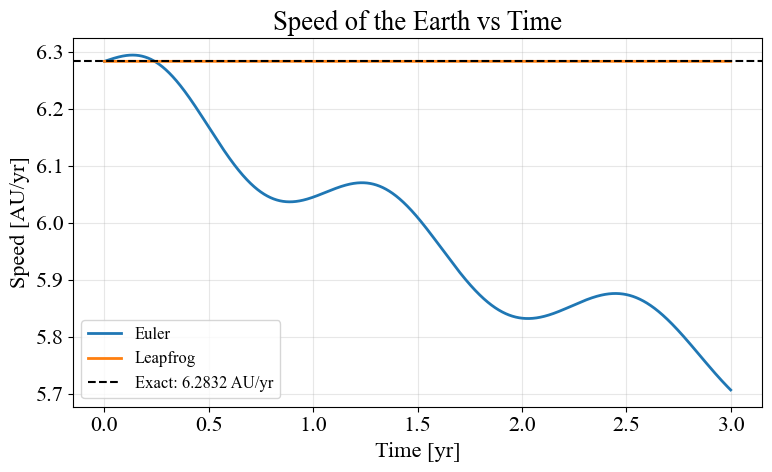

In [150]:
# Plotting speed as a function of time
speed1 = np.sqrt(vx1**2 + vy1**2)
speed2 = np.sqrt(vx2**2 + vy2**2)
t = np.linspace(0,T,N+1) 

v_exact = np.sqrt(GM / r0)          # circular orbital speed
E_exact = 0.5 * v_exact**2 - GM / r0   # exact specific energy

# Speed plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, speed1, label='Euler', linewidth = 2)
ax.plot(t, speed2, label='Leapfrog', linewidth = 2)
ax.axhline(v_exact, color='black', linestyle='--', label=f'Exact: {v_circ:.4f} AU/yr')

ax.set_xlabel("Time [yr]")
ax.set_ylabel(r"Speed [AU/yr]")
ax.set_title(r"Speed of the Earth vs Time")
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("1_speed_vs_time.png", dpi=150, bbox_inches='tight')
plt.show()

### 1c: Total Specific Energy vs Time
The total specific orbital energy is computed at each timestep for both methods:
$$\epsilon = \frac{1}{2}v^2 - \frac{GM_\odot}{r}$$
where $r = \sqrt{x^2 + y^2}$ is the distance from the Sun. The exact analytical value for a circular orbit is:
$$\epsilon_{exact} = \frac{1}{2}v_{circ}^2 - \frac{GM_\odot}{r_0}$$
The energy is plotted as a function of time for both methods alongside the exact value.

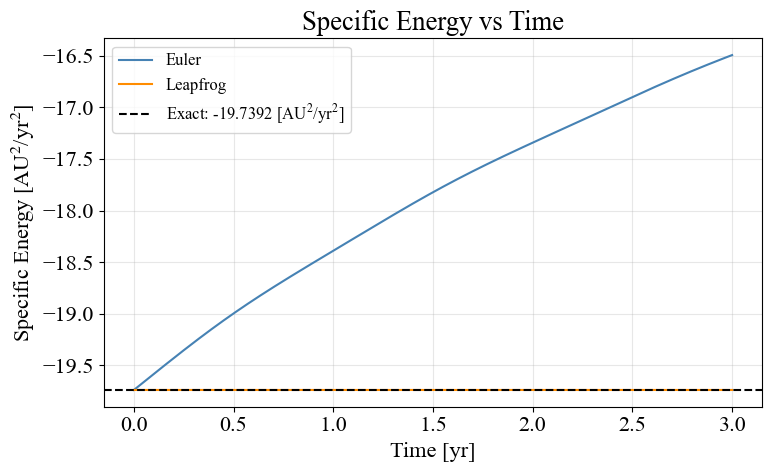

In [151]:
# Total Energy 
r1 = np.sqrt(x1**2 + y1**2)
r2 = np.sqrt(x2**2 + y2**2)
Energy1 = 0.5 * speed1**2 - (GM/r1)
Energy2 = 0.5 * speed2**2 - (GM/r2)
E_exact = 0.5 * v_circ**2 - GM / r0   # exact specific energy
# Energy plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, Energy1, label='Euler', color='steelblue')
ax.plot(t, Energy2, label='Leapfrog', color='darkorange')
ax.axhline(E_exact, color='black', linestyle='--', label=rf'Exact: {E_exact:.4f} [AU$^2$/yr$^2$]')

ax.set_xlabel("Time [yr]")
ax.set_ylabel(r"Specific Energy [AU$^2$/yr$^2$]")
ax.set_title("Specific Energy vs Time")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("1_energy_vs_time.png", dpi=150, bbox_inches='tight')
plt.show()

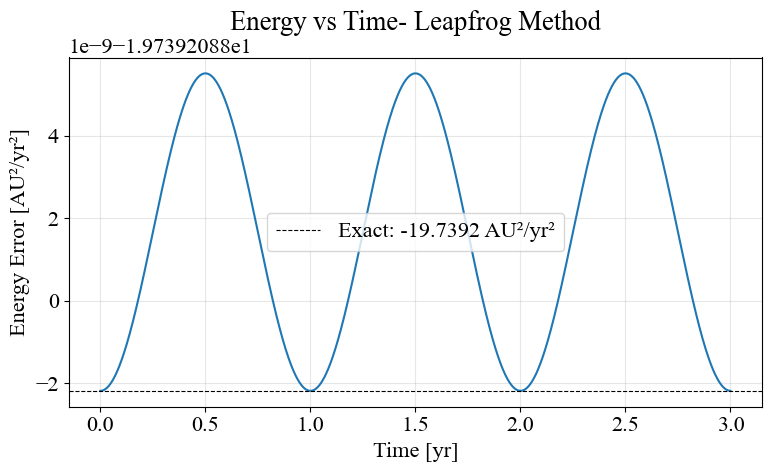

In [152]:
plt.figure(figsize=(8,5))
plt.plot(t, Energy2)
plt.xlabel('Time [yr]')
plt.ylabel('Energy Error [AU²/yr²]')
plt.title('Energy vs Time- Leapfrog Method')
plt.axhline(E_exact, color='k', linestyle='--', linewidth=0.8,label=f'Exact: {E_exact:.4f} AU²/yr²')  # reference line at 0
plt.legend()
plt.savefig("1_Energy_Leapfrog.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()


## Problem 2: Elliptical Orbit with Reduced Initial Velocity

The Earth-Sun two-body simulation is repeated with an initial velocity smaller than the circular orbital velocity:
$$v_0 = 0.8 \, v_{circ}$$
With this reduced velocity, the orbit is no longer circular but elliptical. The motion is integrated over 5 orbital periods using both Euler and Leapfrog methods.

In [153]:
# New Initial conditions – circular orbit at r0 = 1 AU
vy0 = v_circ*0.8

#  Simulation parameters
T_new = 5.0             # 5 orbital periods
dt      = 1e-3            # time step [yr](This is the step size h)
N_new = int(T / dt)

x1,y1,vx1,vy1 = euler_method(x0,y0,vx0,vy0,dt, N_new)
x2,y2,vx2,vy2 = Leapfrog_method(x0,y0,vx0,vy0,dt, N_new)

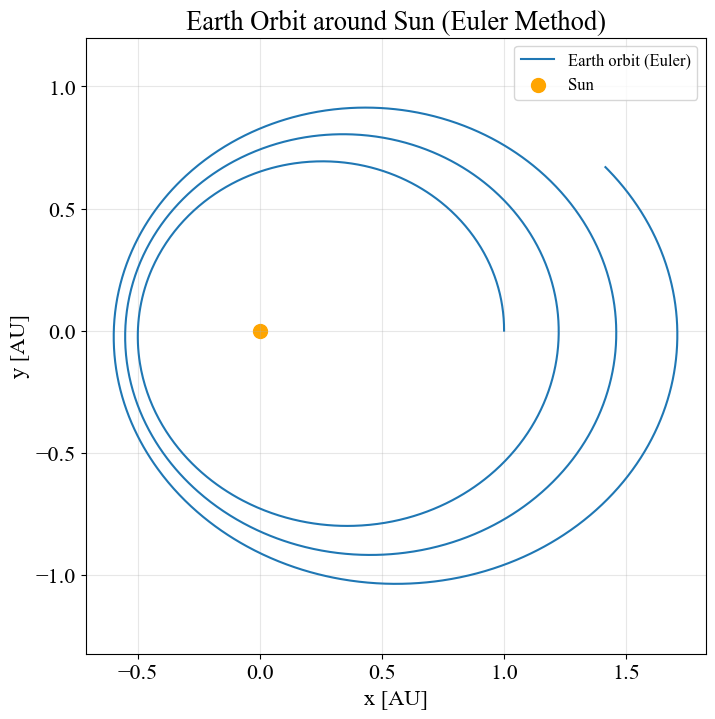

In [154]:
# Plotting the orbit for Euler method
plt.plot(x1, y1, label='Earth orbit (Euler)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Euler Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right",fontsize = 12)
plt.savefig("2_Euler_orbit.png", dpi=150, bbox_inches='tight')
plt.show()

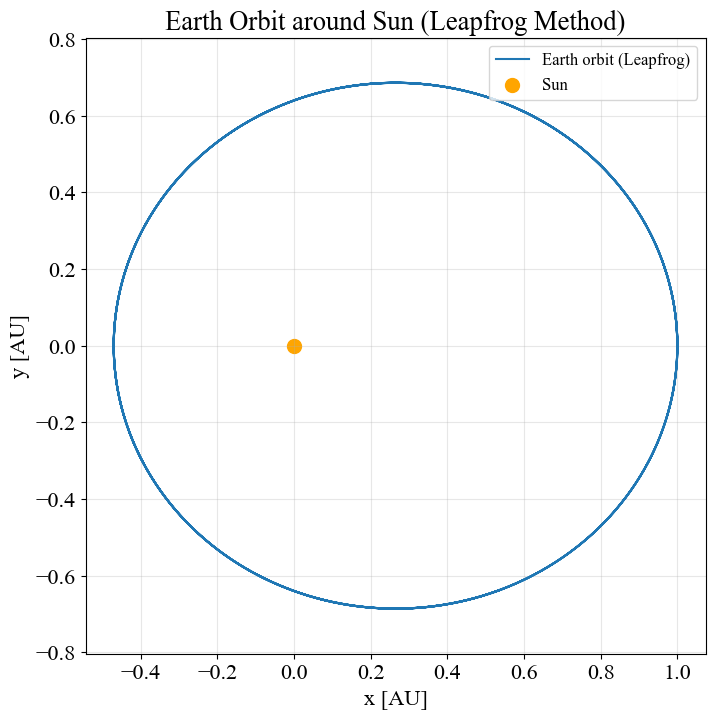

In [155]:
# Plotting the orbit for Leapfrog method
plt.plot(x2, y2, label='Earth orbit (Leapfrog)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Leapfrog Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right",fontsize = 12)
plt.savefig("2_Leapfrog_orbit.png", dpi=150, bbox_inches='tight')
plt.show()

In [156]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Earth Orbiting the Sun (Euler Method)')

# Sun and Earth
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)
orbit_line, = ax.plot([], [], 'b-', alpha=0.4, lw=1)
earth_dot, = ax.plot([], [], 'bo', markersize=10, label='Earth', zorder=10)

ax.legend(loc='upper right',fontsize=12)

def init():
    orbit_line.set_data([], [])
    earth_dot.set_data([], [])
    return orbit_line, earth_dot

# Slow down by using fewer points per frame
points_per_frame = 15  # smaller = slower orbit

def update(i):
    idx = i * points_per_frame
    if idx >= len(x1): idx = len(x1) - 1
    
    orbit_line.set_data(x1[:idx], y1[:idx])
    earth_dot.set_data([x1[idx]], [y1[idx]])
    return orbit_line, earth_dot

# Increase interval to 50ms for smoother slower motion
ani = FuncAnimation(fig, update, frames=len(x1)//points_per_frame, 
                    init_func=init, blit=False, interval=50, repeat=False)

ani.save('2_Euler_orbit.mp4', writer='ffmpeg', fps=30)

plt.close()
display(HTML(ani.to_html5_video()))

In [157]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Earth Orbiting the Sun (Euler Method)')

# Sun and Earth
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)
orbit_line, = ax.plot([], [], 'b-', lw=1)
earth_dot, = ax.plot([], [], 'bo', markersize=10, label='Earth', zorder=10)

ax.legend(loc='upper right',fontsize=12)

def init():
    orbit_line.set_data([], [])
    earth_dot.set_data([], [])
    return orbit_line, earth_dot

# Slow down by using fewer points per frame
points_per_frame = 15  # smaller = slower orbit

def update(i):
    idx = i * points_per_frame
    if idx >= len(x2): idx = len(x2) - 1
    
    orbit_line.set_data(x2[:idx], y2[:idx])
    earth_dot.set_data([x2[idx]], [y2[idx]])
    return orbit_line, earth_dot

# Increase interval to 50ms for smoother slower motion
ani = FuncAnimation(fig, update, frames=len(x1)//points_per_frame, 
                    init_func=init, blit=False, interval=50, repeat=False)

ani.save('2_Leapfrog_orbit.mp4', writer='ffmpeg', fps=30)
plt.close()
display(HTML(ani.to_html5_video()))

### 2b: Total Specific Energy vs Time
The total specific energy:
$$\epsilon = \frac{1}{2}v^2 - \frac{GM_\odot}{r}$$
is plotted as a function of time separately for the Euler and Leapfrog integrators over 5 orbital periods. The exact energy for the elliptical orbit is included as a reference.

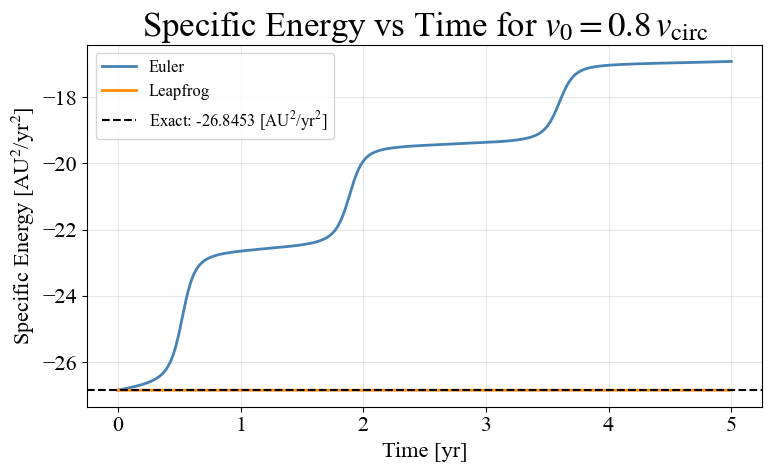

In [158]:
t = np.linspace(0, T_new, N_new+1)
speed1 = np.sqrt(vx1**2 + vy1**2)
speed2 = np.sqrt(vx2**2 + vy2**2)
r1 = np.sqrt(x1**2 + y1**2)
r2 = np.sqrt(x2**2 + y2**2)
Energy1 = 0.5 * speed1**2 - (GM/r1)
Energy2 = 0.5 * speed2**2 - (GM/r2)
e_Exact = 0.5 * vy0**2 - (GM/r0)


# Energy plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, Energy1, label='Euler', color='steelblue',linewidth=2)
ax.plot(t, Energy2, label='Leapfrog', color='darkorange',linewidth=2)
ax.axhline(e_Exact, color='black', linestyle='--', label=rf'Exact: {e_Exact:.4f} [AU$^2$/yr$^2$]')

ax.set_xlabel("Time [yr]")
ax.set_ylabel(r"Specific Energy [AU$^2$/yr$^2$]")
ax.set_title(r"Specific Energy vs Time for $v_0 = 0.8\, v_{\rm circ}$", fontsize=25)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("2_energy_vs_time.png", dpi=150, bbox_inches='tight')
plt.show()


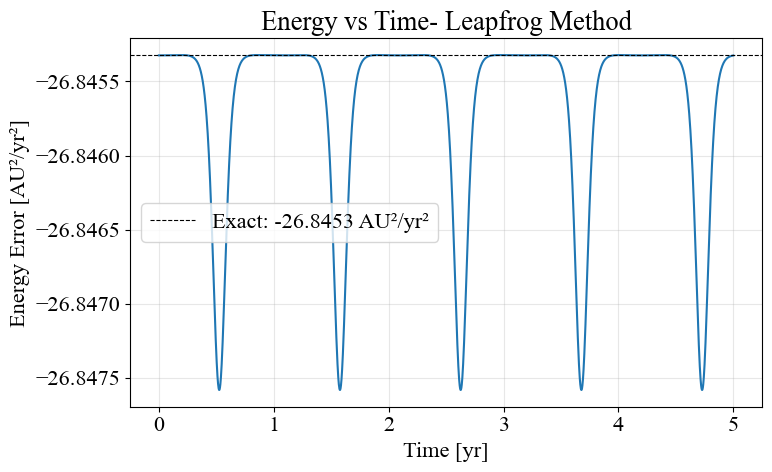

In [159]:
plt.figure(figsize=(8,5))
plt.plot(t, Energy2)
plt.xlabel('Time [yr]')
plt.ylabel('Energy Error [AU²/yr²]')
plt.title('Energy vs Time- Leapfrog Method')
#e_Exact = 0.5 * vy0**2 - (GM/r0)
plt.axhline(e_Exact, color='k', linestyle='--', linewidth=0.8,label=f'Exact: {e_Exact:.4f} AU²/yr²')  # reference line at 0
plt.legend()
plt.ticklabel_format(useOffset=False, style='plain')
plt.savefig("2_Energy_leapfrog.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()